In [3]:
# ================================================================
# LASSO_v2 — PHASE 1: Load dataset & build Target + Validation split
# ================================================================

import pandas as pd
import numpy as np

print("📥 Loading preprocessed dataset for LASSO...")

df = pd.read_csv("../output/training_data_v6_no0min_trial.csv", encoding="utf-8-sig")
print("   → Loaded rows:", len(df))

# Sort
df = df.sort_values(["Player UUID", "season", "Gameweek"]).reset_index(drop=True)

# Create Target_NextGW if missing
if "Target_NextGW" not in df.columns:
    df["Target_NextGW"] = df.groupby(["Player UUID", "season"])["Total Points"].shift(-1)

# Remove rows with no target (last GW per season/player)
before = len(df)
df = df.dropna(subset=["Target_NextGW"]).reset_index(drop=True)
after = len(df)
print(f"🧹 Removed rows with no Target_NextGW: {before - after}")

df["Target_NextGW"] = df["Target_NextGW"].astype(float)

# Build last-5-observation validation split
df["Split"] = "Train"

for uuid, g in df.groupby("Player UUID", sort=False):
    last5 = g.tail(5).index
    df.loc[last5, "Split"] = "Validation"

print(df["Split"].value_counts())
print("✔ Phase 1 complete — Target + Split ready.")


📥 Loading preprocessed dataset for LASSO...
   → Loaded rows: 25735
🧹 Removed rows with no Target_NextGW: 2314
Split
Train         19942
Validation     3479
Name: count, dtype: int64
✔ Phase 1 complete — Target + Split ready.


In [4]:
# ================================================================
# PHASE 2 — Debug last-5 rows per player
# ================================================================

debug = 0

for uuid, g in df.groupby("Player UUID", sort=False):
    if debug < 5:
        print(f"\nPLAYER UUID: {uuid}")
        print(g.tail(5)[["season","Gameweek","Total Points","Target_NextGW","Split"]])
        print("-"*60)
        debug += 1

print("\n✔ Debug complete.")



PLAYER UUID: 00d29d0a-98c1-4730-9e17-1d278cb660ae
     season  Gameweek  Total Points  Target_NextGW       Split
14  2023-24        32             1            1.0  Validation
15  2023-24        34             1            1.0  Validation
16  2023-24        35             1            0.0  Validation
17  2023-24        36             0            2.0  Validation
18  2023-24        37             2            2.0  Validation
------------------------------------------------------------

PLAYER UUID: 00e5b1e6-a33d-4079-aa0e-b31b4c7d2b05
     season  Gameweek  Total Points  Target_NextGW       Split
24  2024-25        33             6            1.0  Validation
25  2024-25        34             1            3.0  Validation
26  2025-26         3             3            0.0  Validation
27  2025-26         4             0            0.0  Validation
28  2025-26         5             0            1.0  Validation
------------------------------------------------------------

PLAYER UUID: 00e8f0

In [5]:
# ================================================================
# PHASE 3 — Prepare X, y for LASSO
# ================================================================

print("🔧 Preparing features for LASSO...")

df_model = df.copy()

cols_to_drop = [
    "Player UUID", "Player Name", "Web Name",
    "Player Team Name", "Opponent Name",
    "season", "Gameweek", "Split"
]

df_model = df_model.drop(columns=cols_to_drop, errors="ignore")

# Target
y = df_model["Target_NextGW"]

# Features
X = df_model.drop(columns=["Target_NextGW"], errors="ignore")

# Fix Is Home
if "Is Home" in X.columns:
    X["Is Home"] = X["Is Home"].replace({True:1, False:0}).astype(int)

# One-hot encode Position
if "Position" in X.columns:
    X["Position"] = X["Position"].fillna("Unknown")
    X = pd.get_dummies(X, columns=["Position"], drop_first=True)

print("📦 Feature matrix shape:", X.shape)
print("✔ Phase 3 complete.")


🔧 Preparing features for LASSO...
📦 Feature matrix shape: (23421, 47)
✔ Phase 3 complete.


C:\Users\SOFI\AppData\Local\Temp\ipykernel_15668\825012863.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Is Home"] = X["Is Home"].replace({True:1, False:0}).astype(int)


In [6]:
# ================================================================
# PHASE 4 — Train/Validation split + Scaling
# ================================================================

from sklearn.preprocessing import StandardScaler

train_mask = df["Split"] == "Train"
val_mask   = df["Split"] == "Validation"

X_train = X.loc[train_mask].reset_index(drop=True)
X_val   = X.loc[val_mask].reset_index(drop=True)
y_train = y.loc[train_mask].reset_index(drop=True)
y_val   = y.loc[val_mask].reset_index(drop=True)

print("Train:", X_train.shape, "Validation:", X_val.shape)

# Scale ONLY on train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_all_scaled   = scaler.transform(X)

print("✔ Scaling complete.")


Train: (19942, 47) Validation: (3479, 47)
✔ Scaling complete.


In [30]:
# ================================================================
# IMPROVED PHASE 5 — Train LASSO with GroupKFold
# ================================================================

from sklearn.linear_model import LassoCV
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("🤖 Training LASSO with GroupKFold CV (player-grouped)…")

# Better alpha range for standardized features
alphas = np.logspace(-4, 0, 100)

# Prepare groups for CV
groups = df.loc[train_mask, 'Player UUID'].values
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train_scaled, y_train, groups=groups))

print(f"   → Created {len(cv_splits)} CV splits grouped by player")

lasso = LassoCV(
    alphas=alphas,
    cv=cv_splits,
    random_state=42,
    max_iter=300000,
    tol=1e-4,
    n_jobs=-1
)

lasso.fit(X_train_scaled, y_train)

y_train_pred = lasso.predict(X_train_scaled)
y_val_pred   = lasso.predict(X_val_scaled)
y_all_pred   = lasso.predict(X_all_scaled)

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae   = mean_absolute_error(y_val, y_val_pred)
val_rmse  = (mean_squared_error(y_val, y_val_pred))**0.5

print("\nSelected Alpha:", lasso.alpha_)
print(f"MAE Train:      {train_mae:.4f}")
print(f"MAE Validation: {val_mae:.4f}")
print(f"RMSE Validation:{val_rmse:.4f}")

print("✔ LASSO training (with GroupKFold) complete.")

🤖 Training LASSO with GroupKFold CV (player-grouped)…
   → Created 5 CV splits grouped by player

Selected Alpha: 0.015199110829529346
MAE Train:      2.1134
MAE Validation: 1.7626
RMSE Validation:2.5061
✔ LASSO training (with GroupKFold) complete.


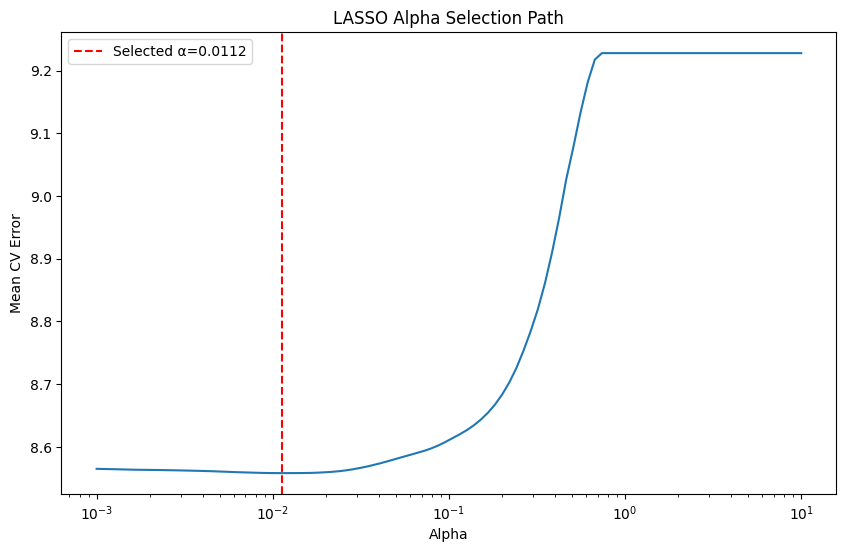

In [19]:
# Visualize alpha selection
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.semilogx(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.axvline(lasso.alpha_, color='r', linestyle='--', label=f'Selected α={lasso.alpha_:.4f}')
plt.xlabel('Alpha')
plt.ylabel('Mean CV Error')
plt.legend()
plt.title('LASSO Alpha Selection Path')
plt.savefig(OUT_DIR / 'alpha_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ================================================================
# PHASE 6 — Export coefficients
# ================================================================

from pathlib import Path

OUT_DIR = Path("../output/lasso_model_v2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso.coef_
})


coef_df.to_csv(OUT_DIR / "coefficients.csv", index=False, encoding="utf-8-sig")

print("✔ Coefficients saved.")
coef_df.head(20)


print(f"\nFeatures retained: {len(non_zero)} out of {len(coef_df)}")
print(f"   Features eliminated: {len(coef_df) - len(non_zero)}")

print("\nTop 20 Most Important Features:")
print(non_zero.head(20))


✔ Coefficients saved.

Features retained: 23 out of 47
   Features eliminated: 24

Top 20 Most Important Features:
                            Feature  Coefficient  Abs_Coef
36             Player_Season_Points     0.296558  0.296558
31                    Avg_Threat_L5     0.230265  0.230265
1                    Minutes Played     0.207082  0.207082
25              Avg_Total Points_L5     0.123443  0.123443
10                        ICT Index     0.107925  0.107925
35                Team_Total_Points    -0.101261  0.101261
9                            Threat     0.075909  0.075909
23                Avg_Creativity_L3     0.068625  0.068625
29            Avg_Goals Conceded_L5    -0.066418  0.066418
13              Opponent Difficulty     0.064328  0.064328
42    Team_Contribution_Rank_Causal    -0.056767  0.056767
8                      Total Points     0.053924  0.053924
0                              Code    -0.053501  0.053501
34             Team_Total_Points_GW     0.047139  0.047139


In [ ]:
# ================================================================
# PHASE 7 — Export predictions
# ================================================================

df_out = df.copy()
df_out["Prediction_For_GW"] = df_out["Gameweek"] + 1
df_out["Total_Points_Actual"] = df_out["Target_NextGW"]
df_out["Total_Points_Predicted"] = y_all_pred
df_out["Error"] = abs(df_out["Total_Points_Actual"] - df_out["Total_Points_Predicted"])

keep = [
    "Player UUID","Player Name","Web Name",
    "season","Prediction_For_GW","Opponent Difficulty",
    "Total_Points_Actual","Total_Points_Predicted",
    "Error","Split"
]

df_final = df_out[keep]

df_final.to_csv(OUT_DIR/"lasso_predictions.csv", index=False, encoding="utf-8-sig")
df_final[df_final["Split"]=="Train"].to_csv(OUT_DIR/"lasso_train.csv", index=False)
df_final[df_final["Split"]=="Validation"].to_csv(OUT_DIR/"lasso_validation.csv", index=False)

split_df = df[["Player UUID","season","Gameweek","Split"]]
split_df.to_csv(OUT_DIR/"lasso_split.csv", index=False)

print("✔ Prediction files exported.")

# Residual analysis
residuals_val = y_val - y_val_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_val_pred, residuals_val, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 3, 2)
plt.hist(residuals_val, bins=50, edgecolor='black')
plt.xlabel('Residuals')
plt.title('Residual Distribution')

plt.subplot(1, 3, 3)
from scipy import stats
stats.probplot(residuals_val, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.savefig(OUT_DIR / 'residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


✔ Prediction files exported.


In [22]:
# ================================================================
# PHASE 8 — Update Model_Performance.csv
# ================================================================

MODEL_PERF = Path("../output/model_performance/Model_Performance.csv")

if MODEL_PERF.exists():
    perf = pd.read_csv(MODEL_PERF)
    perf = perf[~perf["Model"].str.contains("LASSO", na=False)]

    baseline = perf[perf["Model"]=="Rolling Average (TotalPoints)"]
    baseline_mae = baseline["MAE_Validation"].iloc[0] if len(baseline)>0 else val_mae
else:
    perf = pd.DataFrame()
    baseline_mae = val_mae

rel_impr = (baseline_mae - val_mae) / baseline_mae

new_row = pd.DataFrame([{
    "Model":"LASSO Regression (v2)",
    "MAE_Train":round(train_mae,5),
    "MAE_Validation":round(val_mae,5),
    "RMSE_Train":round((mean_squared_error(y_train,y_train_pred))**0.5,5),
    "RMSE_Validation":round(val_rmse,5),
    "Relative_Improvement_vs_Baseline":round(rel_impr,5)
}])

perf = pd.concat([perf,new_row], ignore_index=True)
perf.to_csv(MODEL_PERF, index=False, encoding="utf-8-sig")

print("✔ Model_Performance updated.")


✔ Model_Performance updated.


In [24]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
    alphas=alphas,
    cv=5,
    random_state=42,
    max_iter=300000,
    n_jobs=-1
)
elastic.fit(X_train_scaled, y_train)

,l1_ratio,"[0.1, 0.5, ...]"
,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+01])
,fit_intercept,True
,precompute,'auto'
,max_iter,300000
,tol,0.0001
,cv,5
,copy_X,True
,verbose,0


In [29]:
# Calculate naive baseline (predict last observation)
df_out['Naive_Prediction'] = df.groupby(['Player UUID', 'season'])['Total Points'].shift(1)

# Filter to validation set AND where both values are not NaN
val_complete = df_out.loc[val_mask].copy()
val_complete = val_complete.dropna(subset=['Total_Points_Actual', 'Naive_Prediction'])

naive_mae = mean_absolute_error(
    val_complete['Total_Points_Actual'],
    val_complete['Naive_Prediction']
)
print(f"\nNaive Baseline MAE: {naive_mae:.4f}")
print(f"Valid validation samples: {len(val_complete)}")
print(f"LASSO Improvement: {(naive_mae - val_mae) / naive_mae * 100:.2f}%")


Naive Baseline MAE: 2.0584
Valid validation samples: 3270
LASSO Improvement: 14.55%


In [32]:
from sklearn.model_selection import GroupKFold

# Create the GroupKFold splitter
groups = df.loc[train_mask, 'Player UUID'].values
gkf = GroupKFold(n_splits=5)

# Generate the splits manually
cv_splits = list(gkf.split(X_train_scaled, y_train, groups=groups))

# Pass pre-generated splits to LassoCV
lasso = LassoCV(
    alphas=alphas,
    cv=cv_splits,  # Pass the actual splits, not the splitter
    random_state=42,
    max_iter=300000,
    tol=1e-4,
    n_jobs=-1
)

lasso.fit(X_train_scaled, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+00])
,fit_intercept,True
,precompute,'auto'
,max_iter,300000
,tol,0.0001
,copy_X,True
,cv,"[(array([ 0,...hape=(15953,)), ...), (array([ 14,...hape=(15953,)), ...), ...]"
,verbose,False
,n_jobs,-1


In [27]:
# Export feature importances for future use
importance_df = coef_df[coef_df['Coefficient'] != 0].copy()
importance_df['Importance'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values('Importance', ascending=False)
importance_df.to_csv(OUT_DIR / 'feature_importance.csv', index=False)